# Comparing methods, with statistics + built-in batteries

`compare(...)` trains-free evaluation: give it a few trained models per method
(one per seed), a data loader, and a task name; it computes the task's metrics
per seed and runs a significance test between methods. The result is a
`BenchmarkResult` with a tidy `.summary()` and pairwise `.comparisons`.

In [ ]:
from __future__ import annotations

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from mushin.benchmark import compare

Tiny synthetic 3-class image data (so this runs in seconds, no downloads).

In [ ]:
NUM_CLASSES = 3


def make_loader(n: int = 256, seed: int = 0) -> DataLoader:
    g = torch.Generator().manual_seed(seed)
    y = torch.randint(0, NUM_CLASSES, (n,), generator=g)
    # class-correlated signal so a model can actually learn something
    x = torch.randn(n, 1, 8, 8, generator=g) + y.view(n, 1, 1, 1)
    return DataLoader(TensorDataset(x, y), batch_size=64)


train_loader = make_loader(seed=0)
test_loader = make_loader(n=128, seed=99)

Two tiny classifiers — a conv net and an MLP.

In [ ]:
def small_cnn() -> nn.Module:
    return nn.Sequential(
        nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(),
        nn.AdaptiveAvgPool2d(4), nn.Flatten(),
        nn.Linear(8 * 4 * 4, NUM_CLASSES),
    )


def mlp() -> nn.Module:
    return nn.Sequential(
        nn.Flatten(), nn.Linear(8 * 8, 32), nn.ReLU(), nn.Linear(32, NUM_CLASSES)
    )


def train(model: nn.Module) -> nn.Module:
    opt = torch.optim.Adam(model.parameters(), lr=1e-2)
    model.train()
    for _ in range(3):
        for x, y in train_loader:
            opt.zero_grad()
            nn.functional.cross_entropy(model(x), y).backward()
            opt.step()
    return model.eval()

Train one of each per seed, then `compare` them on the held-out loader.

In [ ]:
methods = {"cnn": [], "mlp": []}
for seed in (0, 1, 2):
    torch.manual_seed(seed)
    methods["cnn"].append(train(small_cnn()))
    methods["mlp"].append(train(mlp()))

result = compare(
    methods, data=test_loader, task="classification",
    num_classes=NUM_CLASSES, test="welch",
)
result.summary()

,method,metric,mean,ci_low,ci_high,significant_vs_ref
0,cnn,accuracy,0.932292,0.657602,1.206981,
1,cnn,f1,0.926364,0.627760,1.224969,
2,cnn,precision,0.948839,0.749432,1.148247,
3,cnn,recall,0.938534,0.689171,1.187898,
4,cnn,auroc,1.000000,1.000000,1.000000,
5,cnn,ece,0.213770,0.134301,0.293239,
6,mlp,accuracy,0.609375,0.473524,0.745226,*
7,mlp,f1,0.565300,0.383766,0.746833,*
8,mlp,precision,0.601869,0.358352,0.845386,*
9,mlp,recall,0.646720,0.523970,0.769470,*


The pairwise comparison, with effect size and (corrected) p-value.

In [ ]:
result.comparisons

,metric,method_a,method_b,mean_diff,effect_size,p_value,p_corrected,significant
0,accuracy,cnn,mlp,0.322917,3.701905,0.021228,0.021228,True
1,f1,cnn,mlp,0.361065,3.629810,0.017270,0.017270,True
2,precision,cnn,mlp,0.346970,3.872800,0.009897,0.009897,True
3,recall,cnn,mlp,0.291814,3.688490,0.021552,0.021552,True
4,auroc,cnn,mlp,0.036862,NaN,NaN,NaN,False
5,ece,cnn,mlp,0.052625,1.356250,0.179304,0.179304,False


Per-method mean accuracy with 95% confidence intervals, straight from
`.summary()`.

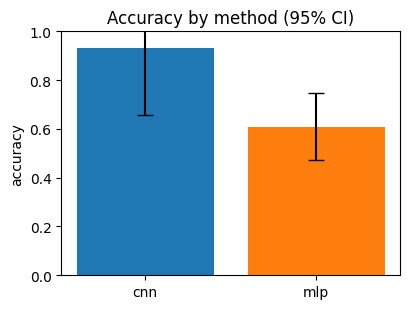

In [ ]:
import matplotlib.pyplot as plt

acc = result.summary().query("metric == 'accuracy'")
fig, ax = plt.subplots(figsize=(4.2, 3.2))
lo = (acc["mean"] - acc["ci_low"]).values
hi = (acc["ci_high"] - acc["mean"]).values
ax.bar(acc["method"], acc["mean"], yerr=[lo, hi], capsize=6,
       color=["tab:blue", "tab:orange"])
ax.set_ylabel("accuracy")
ax.set_ylim(0, 1)
ax.set_title("Accuracy by method (95% CI)")
fig.tight_layout()
plt.show()

## A second battery: regression

The task name is the only thing that changes. Regression needs no
`num_classes`; the passthrough predict_fn feeds `model(x)` straight to the
metrics.

In [ ]:
gg = torch.Generator().manual_seed(0)
xr = torch.randn(64, 1, generator=gg)
yr = xr[:, 0] * 2.0 + 1.0
reg_loader = DataLoader(TensorDataset(xr, yr), batch_size=32)


class Affine(nn.Module):
    def __init__(self, w, b):
        super().__init__()
        self.w, self.b = w, b

    def forward(self, x):
        return x[:, 0] * self.w + self.b


reg_methods = {
    "good": [Affine(2.0, 1.0) for _ in range(3)],
    "bad": [Affine(0.0, 0.0) for _ in range(3)],
}
compare(reg_methods, data=reg_loader, task="regression", test="welch").summary()

/Users/josuemartinez/code/mushin/.venv/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `SpearmanCorrcoef` will save all targets and predictions in the buffer. For large datasets, this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
/Users/josuemartinez/code/mushin/.venv/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: The variance of predictions or target is close to zero. This can cause instability in Pearson correlationcoefficient, leading to wrong results. Consider re-scaling the input if possible or computing using alarger dtype (currently using torch.float32). Setting the correlation coefficient to nan.
  warnings.warn(*args, **kwargs)
/Users/josuemartinez/code/mushin/src/mushin/benchmark/compare.py:77: UserWarning: method 'good' produced identical scores across all 3 seeds — it is deterministic or ignores the seed, so seed-based significance involving it is not meaningful (the seeds are dupli

,method,metric,mean,ci_low,ci_high,significant_vs_ref
0,good,mse,0.000000,0.000000,0.000000,
1,good,mae,0.000000,0.000000,0.000000,
2,good,rmse,0.000000,0.000000,0.000000,
3,good,r2,1.000000,1.000000,1.000000,
4,good,pearson,1.000000,1.000000,1.000000,
5,good,spearman,1.000000,1.000000,1.000000,
6,bad,mse,5.749803,5.749803,5.749803,
7,bad,mae,1.894681,1.894681,1.894681,
8,bad,rmse,2.397875,2.397875,2.397875,
9,bad,r2,-0.323418,-0.323418,-0.323418,


**See also**

- [Comparing methods guide](../guides/compare.md) — every knob on `compare`.
- [Built-in batteries guide](../guides/batteries.md) — all seven tasks with
  real-model recipes (SAM, YOLO-World, CLIP, …).